# Sachs Real-Data — Shapley Results Analysis

Mirrors `shapley_results_analysis.ipynb` but for the **Sachs cell-signalling dataset**.
Loads SHAP values, adjacency matrices, and preprocessed data that were saved by the
`real_data_exploration.ipynb` → *Save Results to Disk* cell.

**Sections**
1. Config & Imports
2. Load Shapley Values
3. Mean |SHAP| & Helper Setup
4. Feature Importance Bar Chart
5. SHAP Scatter — PC Graph
6. SHAP Scatter — LiNGAM Graph
7. Instance-Level SHAP — PC
8. Instance-Level SHAP — LiNGAM
9. DAG Visualization (True / PC / LiNGAM)
10. Graph Sensitivity Score (GSS)
11. Ranking Robustness (Spearman ρ / Top-K Jaccard / True-Parent Precision@K)
12. Sign Stability Score (SSS)
13. Method Recommendation Summary
14. Edge Recovery Table
15. Adjacency Matrix Heatmap
16. Feature Importance CSV Export

## 1. Config & Imports

In [1]:
import sys
from pathlib import Path as _Path
sys.path.insert(0, str(_Path('..').resolve()))

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import json, collections
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import importlib
import analysis_utils
importlib.reload(analysis_utils)

from analysis_utils import (
    resolve_features,
    mean_abs_shap, top_k_jaccard,
    compute_sign_agreement, compute_sign_alignment, compute_tga,
    compute_sss, compute_gss,
    edge_recovery, flow_graph_stats,
    build_dag_graph, make_dag_pos, draw_dag, draw_dag_highlight, PROX_PALETTE,
    make_shap_scatter_figure, make_instance_shap_figure,
)

# ── Dataset / paths ───────────────────────────────────────────────────────────
DATASET = 'sachs'
MODEL   = 'lgbm'

# Show all features (only 10 proteins)
N_TOP_FEATURES = 10

BASE_DIR           = Path('..').resolve()
EXPLAINABILITY_DIR = BASE_DIR / 'data' / 'explainability'
CAUSAL_DIR         = BASE_DIR / 'data' / 'causal'
PROCESSED_DIR      = BASE_DIR / 'data' / 'processed'
SYNTHETIC_DIR      = BASE_DIR / 'data' / 'synthetic'

# ── Consistent colour scheme ──────────────────────────────────────────────────
METHOD_COLORS = {
    'Scratch':     '#636363',
    'Asymmetric':  '#2166ac',
    'Causal':      '#4dac26',
    'ShapleyFlow': '#d01c8b',
}

print(f'Dataset : {DATASET}')
print(f'Model   : {MODEL}')
print(f'Top N   : {N_TOP_FEATURES}')

Dataset : sachs
Model   : lgbm
Top N   : 10


## 2. Load Shapley Values

In [2]:
exp_dir = EXPLAINABILITY_DIR / DATASET / MODEL

METHOD_PATHS = {
    'Scratch':               exp_dir / 'scratch'  / 'shapley_values.npy',
    'Asymmetric (PC)':       exp_dir / 'pc'       / 'asymmetric' / 'shapley_values.npy',
    'Causal (PC)':           exp_dir / 'pc'       / 'causal'     / 'shapley_values.npy',
    'Flow (PC)':             exp_dir / 'pc'       / 'flow'       / 'shapley_values.npy',
    'Asymmetric (LiNGAM)':  exp_dir / 'lingam'   / 'asymmetric' / 'shapley_values.npy',
    'Causal (LiNGAM)':      exp_dir / 'lingam'   / 'causal'     / 'shapley_values.npy',
    'Flow (LiNGAM)':        exp_dir / 'lingam'   / 'flow'       / 'shapley_values.npy',
}

shap_data = {}
for name, path in METHOD_PATHS.items():
    if path.exists():
        sv = np.load(path)
        shap_data[name] = sv
        nan_pct  = 100 * np.isnan(sv).mean()
        zero_pct = 100 * (sv == 0).mean()
        print(f'  {name:28s}  shape={sv.shape}  '
              f'mean|SHAP|={np.abs(sv).mean():.4f}  '
              f'NaN={nan_pct:.1f}%  zeros={zero_pct:.1f}%')
    else:
        print(f'  {name:28s}  NOT FOUND: {path}')

# ── Feature names (X only, no Y) ──────────────────────────────────────────────
with open(CAUSAL_DIR / f'{DATASET}_pc_results.json') as f:
    pc_results = json.load(f)
with open(CAUSAL_DIR / f'{DATASET}_lingam_results.json') as f:
    lingam_results = json.load(f)

feature_names = [n for n in pc_results['feature_names'] if n != 'Y']
n_features    = len(feature_names)

# ── Test instances ────────────────────────────────────────────────────────────
n_shap  = shap_data['Scratch'].shape[0]
test_df = pd.read_parquet(PROCESSED_DIR / f'{DATASET}_test.parquet')
x_test  = test_df[feature_names].iloc[:n_shap].values   # (n_shap, n_features)

# ── Graph statistics ──────────────────────────────────────────────────────────
pc_edges,     pc_sources     = flow_graph_stats(pc_results['adjacency_matrix'],     n_features)
lingam_edges, lingam_sources = flow_graph_stats(lingam_results['adjacency_matrix'], n_features)

print(f'\nFeatures : {n_features}    SHAP instances : {n_shap}')
print(f'PC graph     : {pc_edges} edges, {pc_sources} sources')
print(f'LiNGAM graph : {lingam_edges} edges, {lingam_sources} sources')

  Scratch                       shape=(100, 10)  mean|SHAP|=7.7904  NaN=0.0%  zeros=0.0%
  Asymmetric (PC)               shape=(100, 10)  mean|SHAP|=8.2030  NaN=0.0%  zeros=0.0%
  Causal (PC)                   shape=(100, 10)  mean|SHAP|=8.7927  NaN=0.0%  zeros=0.0%
  Flow (PC)                     shape=(100, 10)  mean|SHAP|=8.3617  NaN=0.0%  zeros=2.9%
  Asymmetric (LiNGAM)           shape=(100, 10)  mean|SHAP|=8.0255  NaN=0.0%  zeros=0.0%
  Causal (LiNGAM)               shape=(100, 10)  mean|SHAP|=8.7352  NaN=0.0%  zeros=0.0%
  Flow (LiNGAM)                 shape=(100, 10)  mean|SHAP|=7.9476  NaN=0.0%  zeros=3.6%

Features : 10    SHAP instances : 100
PC graph     : 29 edges, 3 sources
LiNGAM graph : 36 edges, 1 sources


## 3. Mean |SHAP| & Helper Setup

In [3]:
# ── Mean absolute SHAP per feature ────────────────────────────────────────────
mean_abs = {name: np.abs(sv).mean(axis=0) for name, sv in shap_data.items()}

# All features ranked by Scratch importance (only 10 proteins)
scratch_rank = np.argsort(mean_abs['Scratch'])[::-1][:N_TOP_FEATURES]
top_features = [feature_names[i] for i in scratch_rank]


def _resolve_features(features=None):
    """Thin wrapper — delegates to analysis_utils.resolve_features."""
    return resolve_features(feature_names, scratch_rank, top_features, features)


# ── Method lists ──────────────────────────────────────────────────────────────
PC_METHODS     = ['Scratch', 'Asymmetric (PC)',     'Causal (PC)',     'Flow (PC)']
LINGAM_METHODS = ['Scratch', 'Asymmetric (LiNGAM)', 'Causal (LiNGAM)', 'Flow (LiNGAM)']

print('Mean |SHAP| per method (all features):')
for name, ma in mean_abs.items():
    print(f'  {name:28s}  {ma.mean():.4f}')

Mean |SHAP| per method (all features):
  Scratch                       7.7904
  Asymmetric (PC)               8.2030
  Causal (PC)                   8.7927
  Flow (PC)                     8.3617
  Asymmetric (LiNGAM)           8.0255
  Causal (LiNGAM)               8.7352
  Flow (LiNGAM)                 7.9476


## 4. Feature Importance Bar Chart

In [4]:
def plot_feature_importance(features=None):
    feat_idx, feat_labels = _resolve_features(features)
    title_tag = f'Top {N_TOP_FEATURES}' if features is None else f'{len(feat_labels)}'

    rows = []
    for method in PC_METHODS:
        src_key = 'Scratch' if method == 'Scratch' else method
        if src_key not in mean_abs:
            continue
        label = method.replace(' (PC)', '')
        for fi in feat_idx:
            rows.append(dict(
                Feature=feature_names[fi],
                Method=label,
                Graph=f'PC  ({pc_edges} edges, {pc_sources} sources)',
                Importance=float(mean_abs[src_key][fi]),
            ))

    for method in LINGAM_METHODS:
        src_key = 'Scratch' if method == 'Scratch' else method
        if src_key not in mean_abs:
            continue
        label = method.replace(' (LiNGAM)', '')
        for fi in feat_idx:
            rows.append(dict(
                Feature=feature_names[fi],
                Method=label,
                Graph=f'LiNGAM  ({lingam_edges} edges, {lingam_sources} sources)',
                Importance=float(mean_abs[src_key][fi]),
            ))

    df_imp = pd.DataFrame(rows)
    df_imp['Feature'] = pd.Categorical(df_imp['Feature'], categories=feat_labels, ordered=True)

    fig = px.bar(
        df_imp,
        x='Feature', y='Importance', color='Method',
        barmode='group',
        facet_col='Graph',
        facet_col_spacing=0.06,
        category_orders={
            'Feature': feat_labels,
            'Method':  ['Scratch', 'Asymmetric', 'Causal', 'Flow'],
        },
        color_discrete_map={
            'Scratch':    METHOD_COLORS['Scratch'],
            'Asymmetric': METHOD_COLORS['Asymmetric'],
            'Causal':     METHOD_COLORS['Causal'],
            'Flow':       METHOD_COLORS['ShapleyFlow'],
        },
        labels={'Importance': 'Mean |SHAP|', 'Feature': ''},
        title=(
            f'Global Feature Importance — {title_tag} Features '
            f'(sorted by Scratch) — {DATASET}'
        ),
        height=480,
        width=1100,
    )
    fig.update_yaxes(matches='y')
    fig.update_layout(legend_title_text='Method', margin=dict(t=80, b=60))
    fig.show()
    return fig


fig_imp = plot_feature_importance()

## 5. SHAP Scatter — PC Graph

In [5]:
PC_SCATTER_METHODS = ['Scratch', 'Asymmetric (PC)', 'Causal (PC)', 'Flow (PC)']
COL_LABELS         = ['ShapleyFromScratch', 'AsymmetricShapley', 'CausalShapley', 'ShapleyFlow']


def plot_shap_scatter_pc(features=None):
    feat_idx, feat_labels = _resolve_features(features)
    title_tag = f'Top {N_TOP_FEATURES}' if features is None else f'{len(feat_labels)}'
    fig = make_shap_scatter_figure(
        methods        = PC_SCATTER_METHODS,
        col_labels     = COL_LABELS,
        feature_idx    = feat_idx,
        feature_labels = feat_labels,
        x_test         = x_test,
        shap_data      = shap_data,
        title          = (
            f'SHAP Scatter — PC Graph ({pc_edges} edges, {pc_sources} sources) — '
            f'{title_tag} Features — {DATASET}'
        ),
        colors         = METHOD_COLORS,
    )
    fig.show()
    return fig


fig_scatter_pc = plot_shap_scatter_pc()

## 6. SHAP Scatter — LiNGAM Graph

In [6]:
LINGAM_SCATTER_METHODS = ['Scratch', 'Asymmetric (LiNGAM)', 'Causal (LiNGAM)', 'Flow (LiNGAM)']


def plot_shap_scatter_lingam(features=None):
    feat_idx, feat_labels = _resolve_features(features)
    title_tag = f'Top {N_TOP_FEATURES}' if features is None else f'{len(feat_labels)}'
    fig = make_shap_scatter_figure(
        methods        = LINGAM_SCATTER_METHODS,
        col_labels     = COL_LABELS,
        feature_idx    = feat_idx,
        feature_labels = feat_labels,
        x_test         = x_test,
        shap_data      = shap_data,
        title          = (
            f'SHAP Scatter — LiNGAM Graph ({lingam_edges} edges, {lingam_sources} sources) — '
            f'{title_tag} Features — {DATASET}'
        ),
        colors         = METHOD_COLORS,
    )
    fig.show()
    return fig


fig_scatter_lingam = plot_shap_scatter_lingam()

## 7. Instance-Level SHAP — PC

In [7]:
N_INSTANCES  = 10
_rng         = np.random.default_rng(seed=42)
instance_idx = sorted(_rng.choice(len(x_test), size=N_INSTANCES, replace=False).tolist())
print(f'Selected {N_INSTANCES} instances (seed=42): {instance_idx}')


def plot_instance_shap_pc(features=None):
    feat_idx, feat_labels = _resolve_features(features)
    title_tag = f'Top {N_TOP_FEATURES}' if features is None else f'{len(feat_labels)}'
    fig = make_instance_shap_figure(
        methods        = PC_SCATTER_METHODS,
        col_labels     = COL_LABELS,
        feature_idx    = feat_idx,
        feature_labels = feat_labels,
        instance_idx   = instance_idx,
        shap_data      = shap_data,
        title          = (
            f'Instance-Level SHAP — PC Graph ({pc_edges} edges, {pc_sources} sources) — '
            f'{title_tag} Features — {DATASET}'
        ),
    )
    fig.show()
    return fig


fig_instance_pc = plot_instance_shap_pc()

Selected 10 instances (seed=42): [8, 9, 19, 41, 60, 68, 71, 82, 94, 96]


## 8. Instance-Level SHAP — LiNGAM

In [8]:
def plot_instance_shap_lingam(features=None):
    feat_idx, feat_labels = _resolve_features(features)
    title_tag = f'Top {N_TOP_FEATURES}' if features is None else f'{len(feat_labels)}'
    fig = make_instance_shap_figure(
        methods        = LINGAM_SCATTER_METHODS,
        col_labels     = COL_LABELS,
        feature_idx    = feat_idx,
        feature_labels = feat_labels,
        instance_idx   = instance_idx,
        shap_data      = shap_data,
        title          = (
            f'Instance-Level SHAP — LiNGAM Graph ({lingam_edges} edges, {lingam_sources} sources) — '
            f'{title_tag} Features — {DATASET}'
        ),
    )
    fig.show()
    return fig


fig_instance_lingam = plot_instance_shap_lingam()

## 9. DAG Visualization — True / PC / LiNGAM

Nodes are coloured by **BFS distance from Y** (sink).

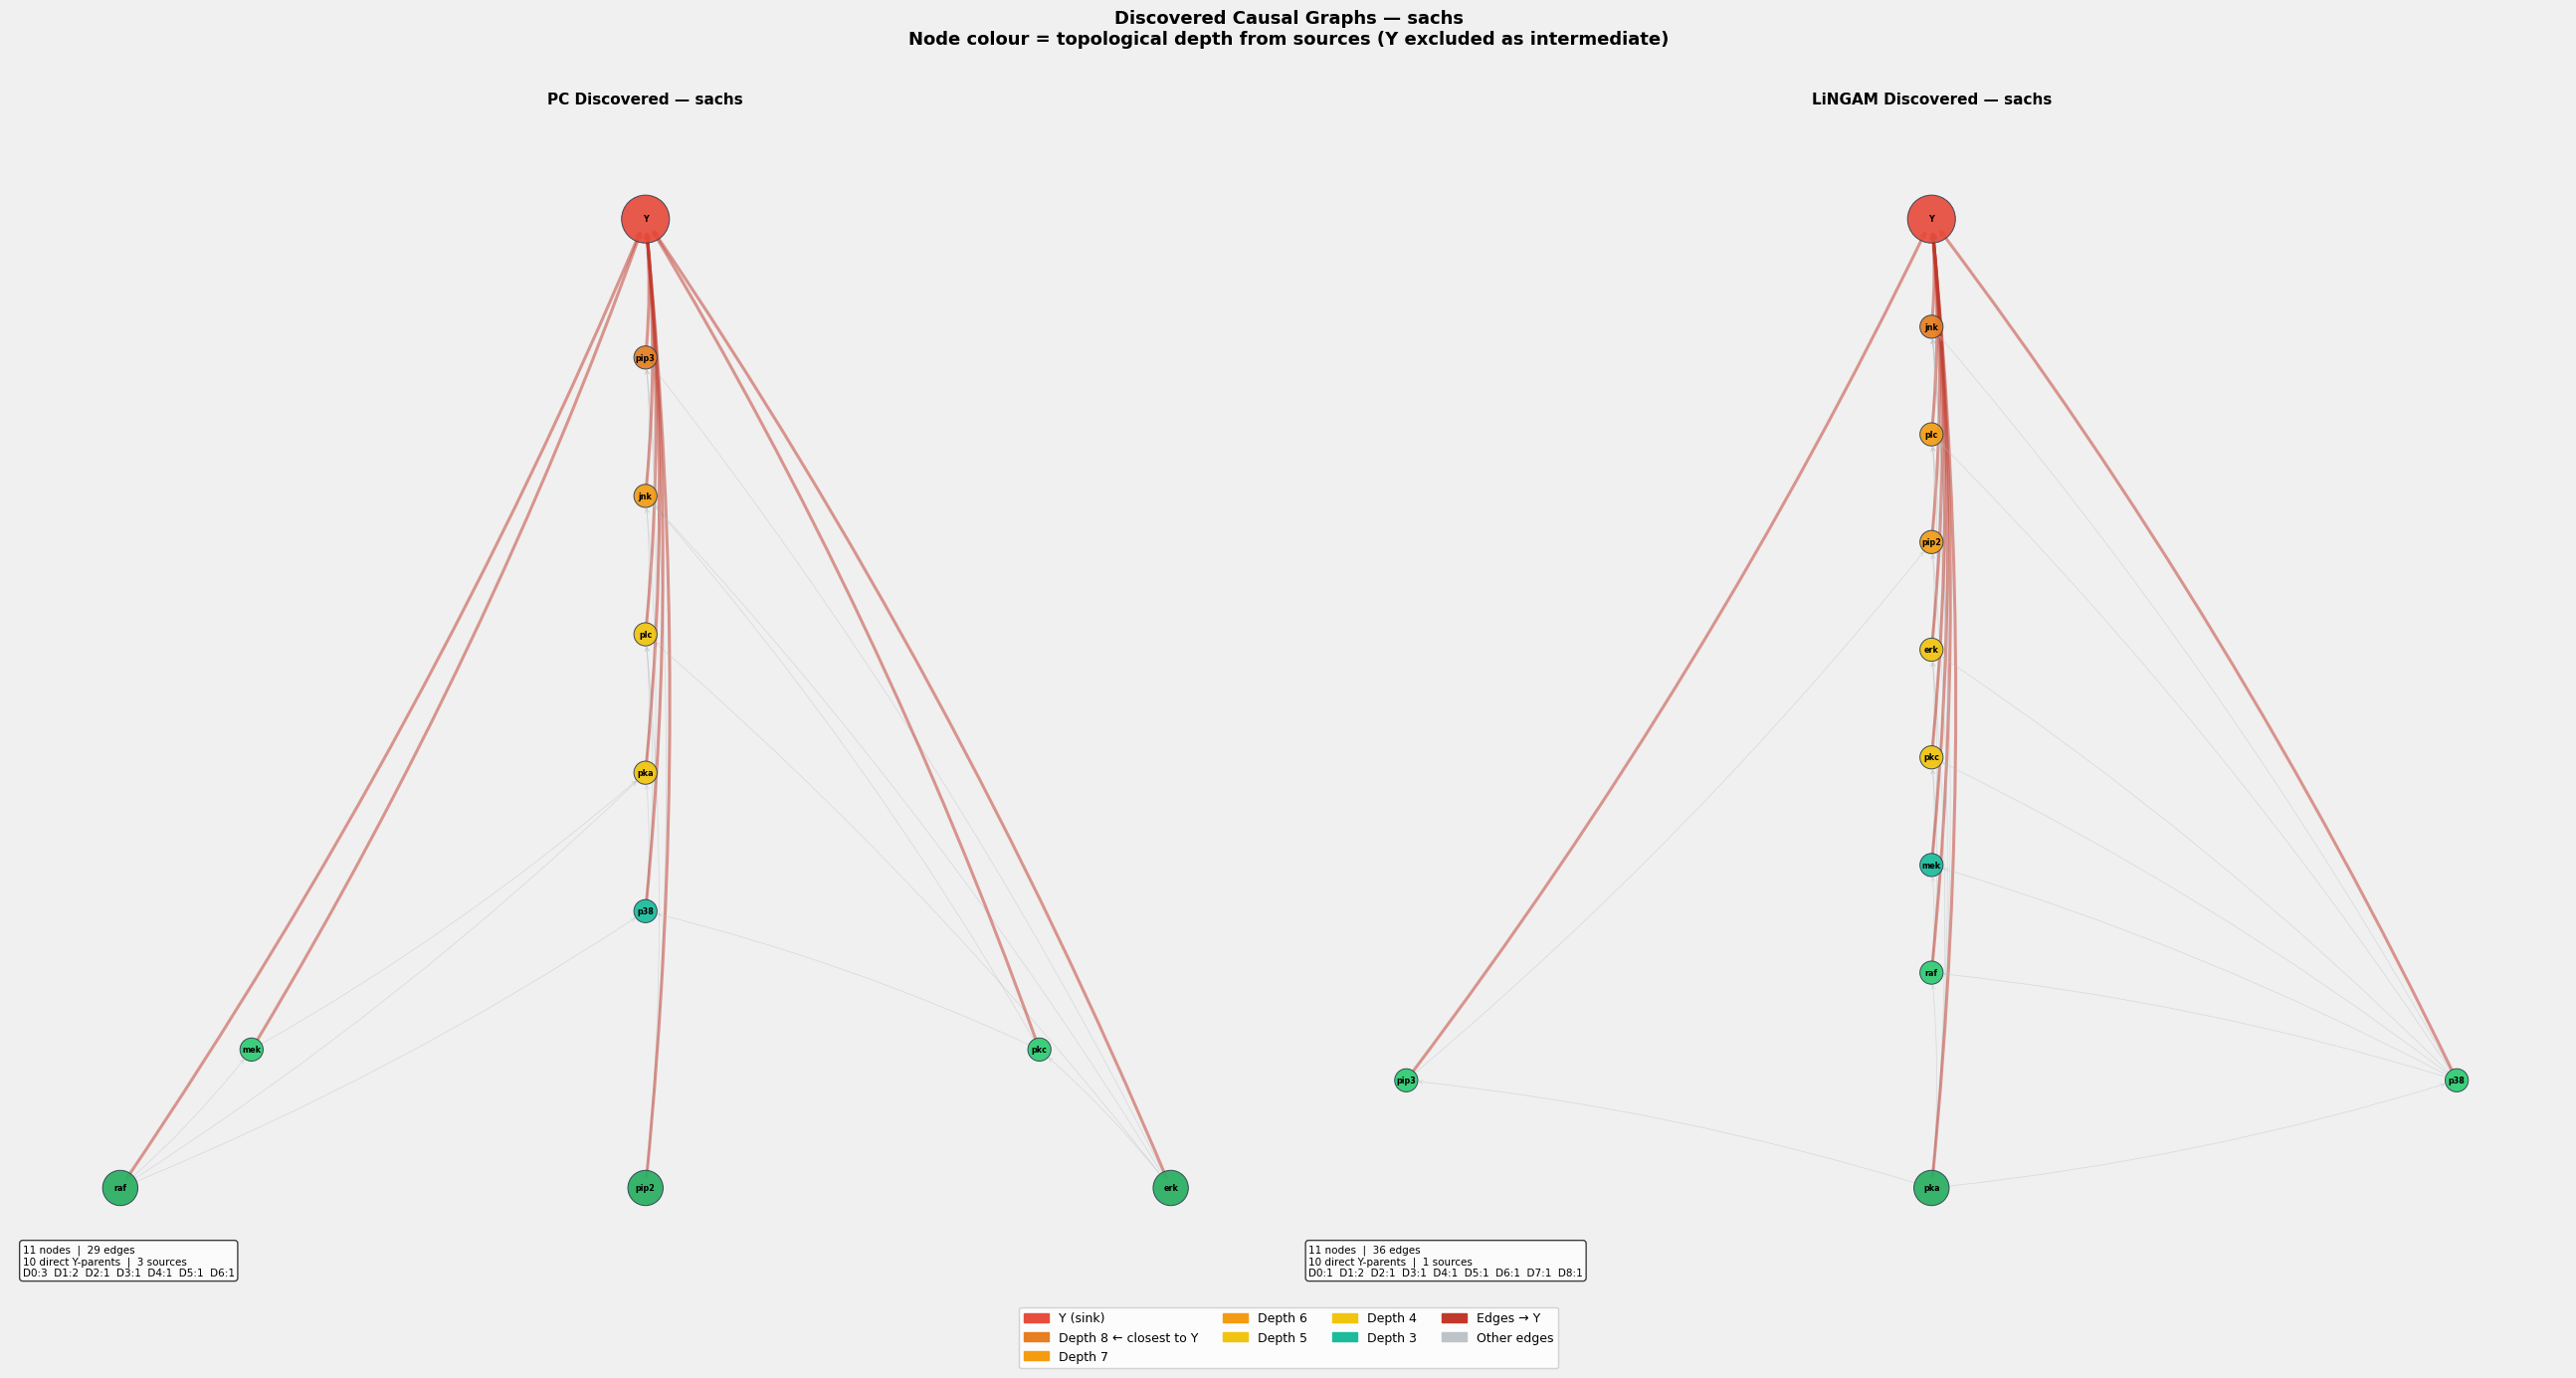


Metric                                 True         PC     LiNGAM
────────────────────────────────────────────────────────────────
  Total nodes                           11        11        11
  Total edges                           25        29        36
  Direct Y-parents                      10        10        10
  Source nodes (depth 0)                 2         3         1
  Max topo depth                         6         6         8
  Nodes at depth 0                       2         3         1
  Nodes at depth 1                       1         2         2
  Nodes at depth 2                       1         1         1
  Nodes at depth 3                       1         1         1
  Nodes at depth 4                       3         1         1
  Nodes at depth 5                       1         1         1
  Nodes at depth 6                       1         1         1
  Nodes at depth 7                       0         0         1
  Nodes at depth 8 (closest to Y)         0      

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Load adjacency matrices ───────────────────────────────────────────────────
true_adj   = np.load(CAUSAL_DIR / f'{DATASET}_true_full_adjacency.npy')
pc_adj     = np.array(pc_results['adjacency_matrix'])
lingam_adj = np.array(lingam_results['adjacency_matrix'])

true_names = pc_results['feature_names']   # same ordering (proteins + Y)
pc_names   = pc_results['feature_names']
lingam_names = lingam_results['feature_names']

# ── Build graphs (analysis_utils — integer-indexed nodes) ─────────────────────
G_true,   td_true,   lvg_true,   src_true,   y_true,   ml_true   = build_dag_graph(true_adj,   true_names)
G_pc,     td_pc,     lvg_pc,     src_pc,     y_pc,     ml_pc     = build_dag_graph(pc_adj,     pc_names)
G_lingam, td_lingam, lvg_lingam, src_lingam, y_lingam, ml_lingam = build_dag_graph(lingam_adj, lingam_names)

pos_true   = make_dag_pos(lvg_true,   ml_true)
pos_pc     = make_dag_pos(lvg_pc,     ml_pc)
pos_lingam = make_dag_pos(lvg_lingam, ml_lingam)

# ── 2-panel: PC | LiNGAM ─────────────────────────────────────────────────────
fig_dags, axes = plt.subplots(1, 2, figsize=(26, 14))
fig_dags.patch.set_facecolor('#f0f0f0')

draw_dag(axes[0], G_pc,     pos_pc,     td_pc,     src_pc,     y_pc,     ml_pc,
         f'PC Discovered — {DATASET}')
draw_dag(axes[1], G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
         f'LiNGAM Discovered — {DATASET}')

max_lv_disc = max(ml_pc, ml_lingam)
legend_entries = [mpatches.Patch(color='#e74c3c', label='Y (sink)')]
for prox in range(min(len(PROX_PALETTE), max_lv_disc + 1)):
    idx = int(round(prox / max(max_lv_disc, 1) * (len(PROX_PALETTE) - 1)))
    col = PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]
    d   = max_lv_disc - prox
    lbl = (f'Depth {d} — sources (no parents)' if prox == max_lv_disc
           else f'Depth {d}' + (' ← closest to Y' if prox == 0 else ''))
    legend_entries.append(mpatches.Patch(color=col, label=lbl))
legend_entries += [mpatches.Patch(color='#c0392b', label='Edges → Y'),
                   mpatches.Patch(color='#bdc3c7', label='Other edges')]
fig_dags.legend(handles=legend_entries, loc='lower center', ncol=4, fontsize=9,
                framealpha=0.85, bbox_to_anchor=(0.5, 0.01))
fig_dags.suptitle(
    f'Discovered Causal Graphs — {DATASET}\n'
    f'Node colour = topological depth from sources (Y excluded as intermediate)',
    fontsize=13, fontweight='bold', y=0.99,
)
plt.tight_layout(rect=[0, 0.06, 1, 0.98])
plt.show()

# ── Comparison table ──────────────────────────────────────────────────────────
rows_table = {}
for label, G, td, src, y_i, ml in [
    ('True',   G_true,   td_true,   src_true,   y_true,   ml_true),
    ('PC',     G_pc,     td_pc,     src_pc,     y_pc,     ml_pc),
    ('LiNGAM', G_lingam, td_lingam, src_lingam, y_lingam, ml_lingam),
]:
    rows_table[label] = {
        'nodes':      G.number_of_nodes(),
        'edges':      G.number_of_edges(),
        'direct_y':   sum(1 for u, v in G.edges() if v == y_i),
        'sources':    len(src),
        'max_depth':  ml,
        'depth_dist': collections.Counter(v for k, v in td.items() if k != y_i),
    }

def _fmt(d, key): return f'{d[key]:>10}'

print(f"\n{'Metric':<32} {'True':>10} {'PC':>10} {'LiNGAM':>10}")
print('─' * 64)
print(f"  {'Total nodes':<30}" + ''.join(_fmt(rows_table[m], 'nodes')     for m in ['True','PC','LiNGAM']))
print(f"  {'Total edges':<30}" + ''.join(_fmt(rows_table[m], 'edges')     for m in ['True','PC','LiNGAM']))
print(f"  {'Direct Y-parents':<30}" + ''.join(_fmt(rows_table[m], 'direct_y')  for m in ['True','PC','LiNGAM']))
print(f"  {'Source nodes (depth 0)':<30}" + ''.join(_fmt(rows_table[m], 'sources')   for m in ['True','PC','LiNGAM']))
print(f"  {'Max topo depth':<30}" + ''.join(_fmt(rows_table[m], 'max_depth') for m in ['True','PC','LiNGAM']))
max_d_all = max(rows_table[m]['max_depth'] for m in rows_table)
for d in range(max_d_all + 1):
    note = ' (closest to Y)' if d == max_d_all else ''
    vals = ''.join(f"{rows_table[m]['depth_dist'].get(d, 0):>10}" for m in ['True','PC','LiNGAM'])
    print(f"  {'Nodes at depth ' + str(d) + note:<30}" + vals)

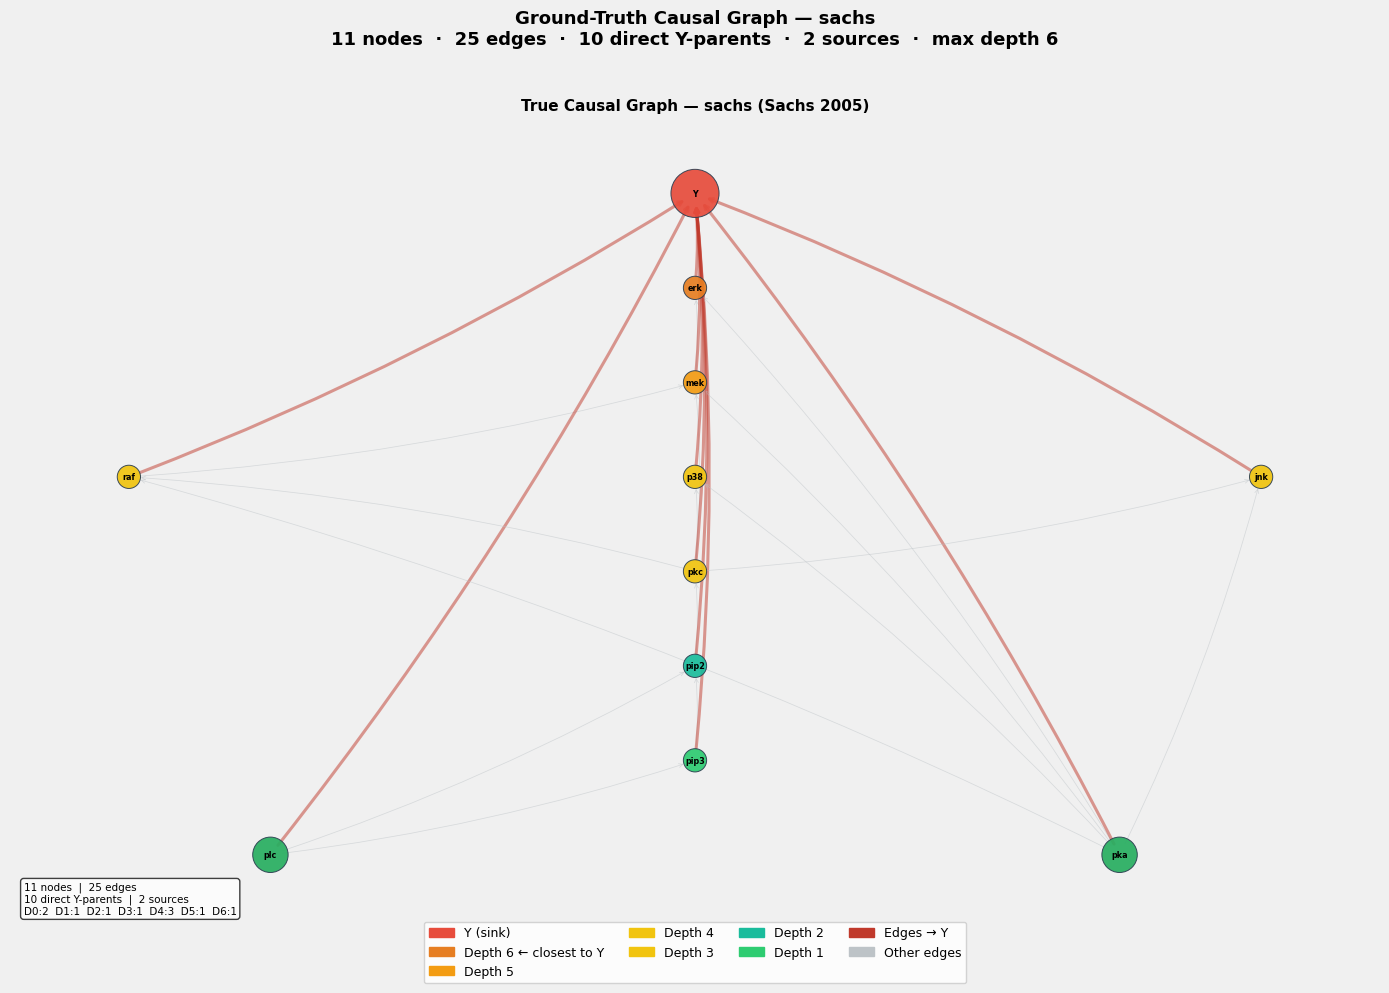

In [10]:
# ── True (ground-truth) causal graph — standalone panel ───────────────────────
fig_true, ax_true = plt.subplots(1, 1, figsize=(14, 10))
fig_true.patch.set_facecolor('#f0f0f0')

draw_dag(ax_true, G_true, pos_true, td_true, src_true, y_true, ml_true,
         f'True Causal Graph — {DATASET} (Sachs 2005)')

legend_entries_true = [mpatches.Patch(color='#e74c3c', label='Y (sink)')]
for prox in range(min(len(PROX_PALETTE), ml_true + 1)):
    idx = int(round(prox / max(ml_true, 1) * (len(PROX_PALETTE) - 1)))
    col = PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]
    d   = ml_true - prox
    lbl = (f'Depth {d} — sources (no parents)' if prox == ml_true
           else f'Depth {d}' + (' ← closest to Y' if prox == 0 else ''))
    legend_entries_true.append(mpatches.Patch(color=col, label=lbl))
legend_entries_true += [mpatches.Patch(color='#c0392b', label='Edges → Y'),
                        mpatches.Patch(color='#bdc3c7', label='Other edges')]
fig_true.legend(handles=legend_entries_true, loc='lower center', ncol=4, fontsize=9,
                framealpha=0.85, bbox_to_anchor=(0.5, 0.01))
fig_true.suptitle(
    f'Ground-Truth Causal Graph — {DATASET}\n'
    f'{G_true.number_of_nodes()} nodes  ·  {G_true.number_of_edges()} edges  ·  '
    f'{sum(1 for u,v in G_true.edges() if v==y_true)} direct Y-parents  ·  '
    f'{len(src_true)} sources  ·  max depth {ml_true}',
    fontsize=13, fontweight='bold', y=0.99,
)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.show()

### 9b — DAG Node Highlight

Highlight a specific protein in both PC and LiNGAM graphs to understand its causal neighbourhood.
**Blue** arrows = incoming (parents). **Orange-red** arrows = outgoing (children).

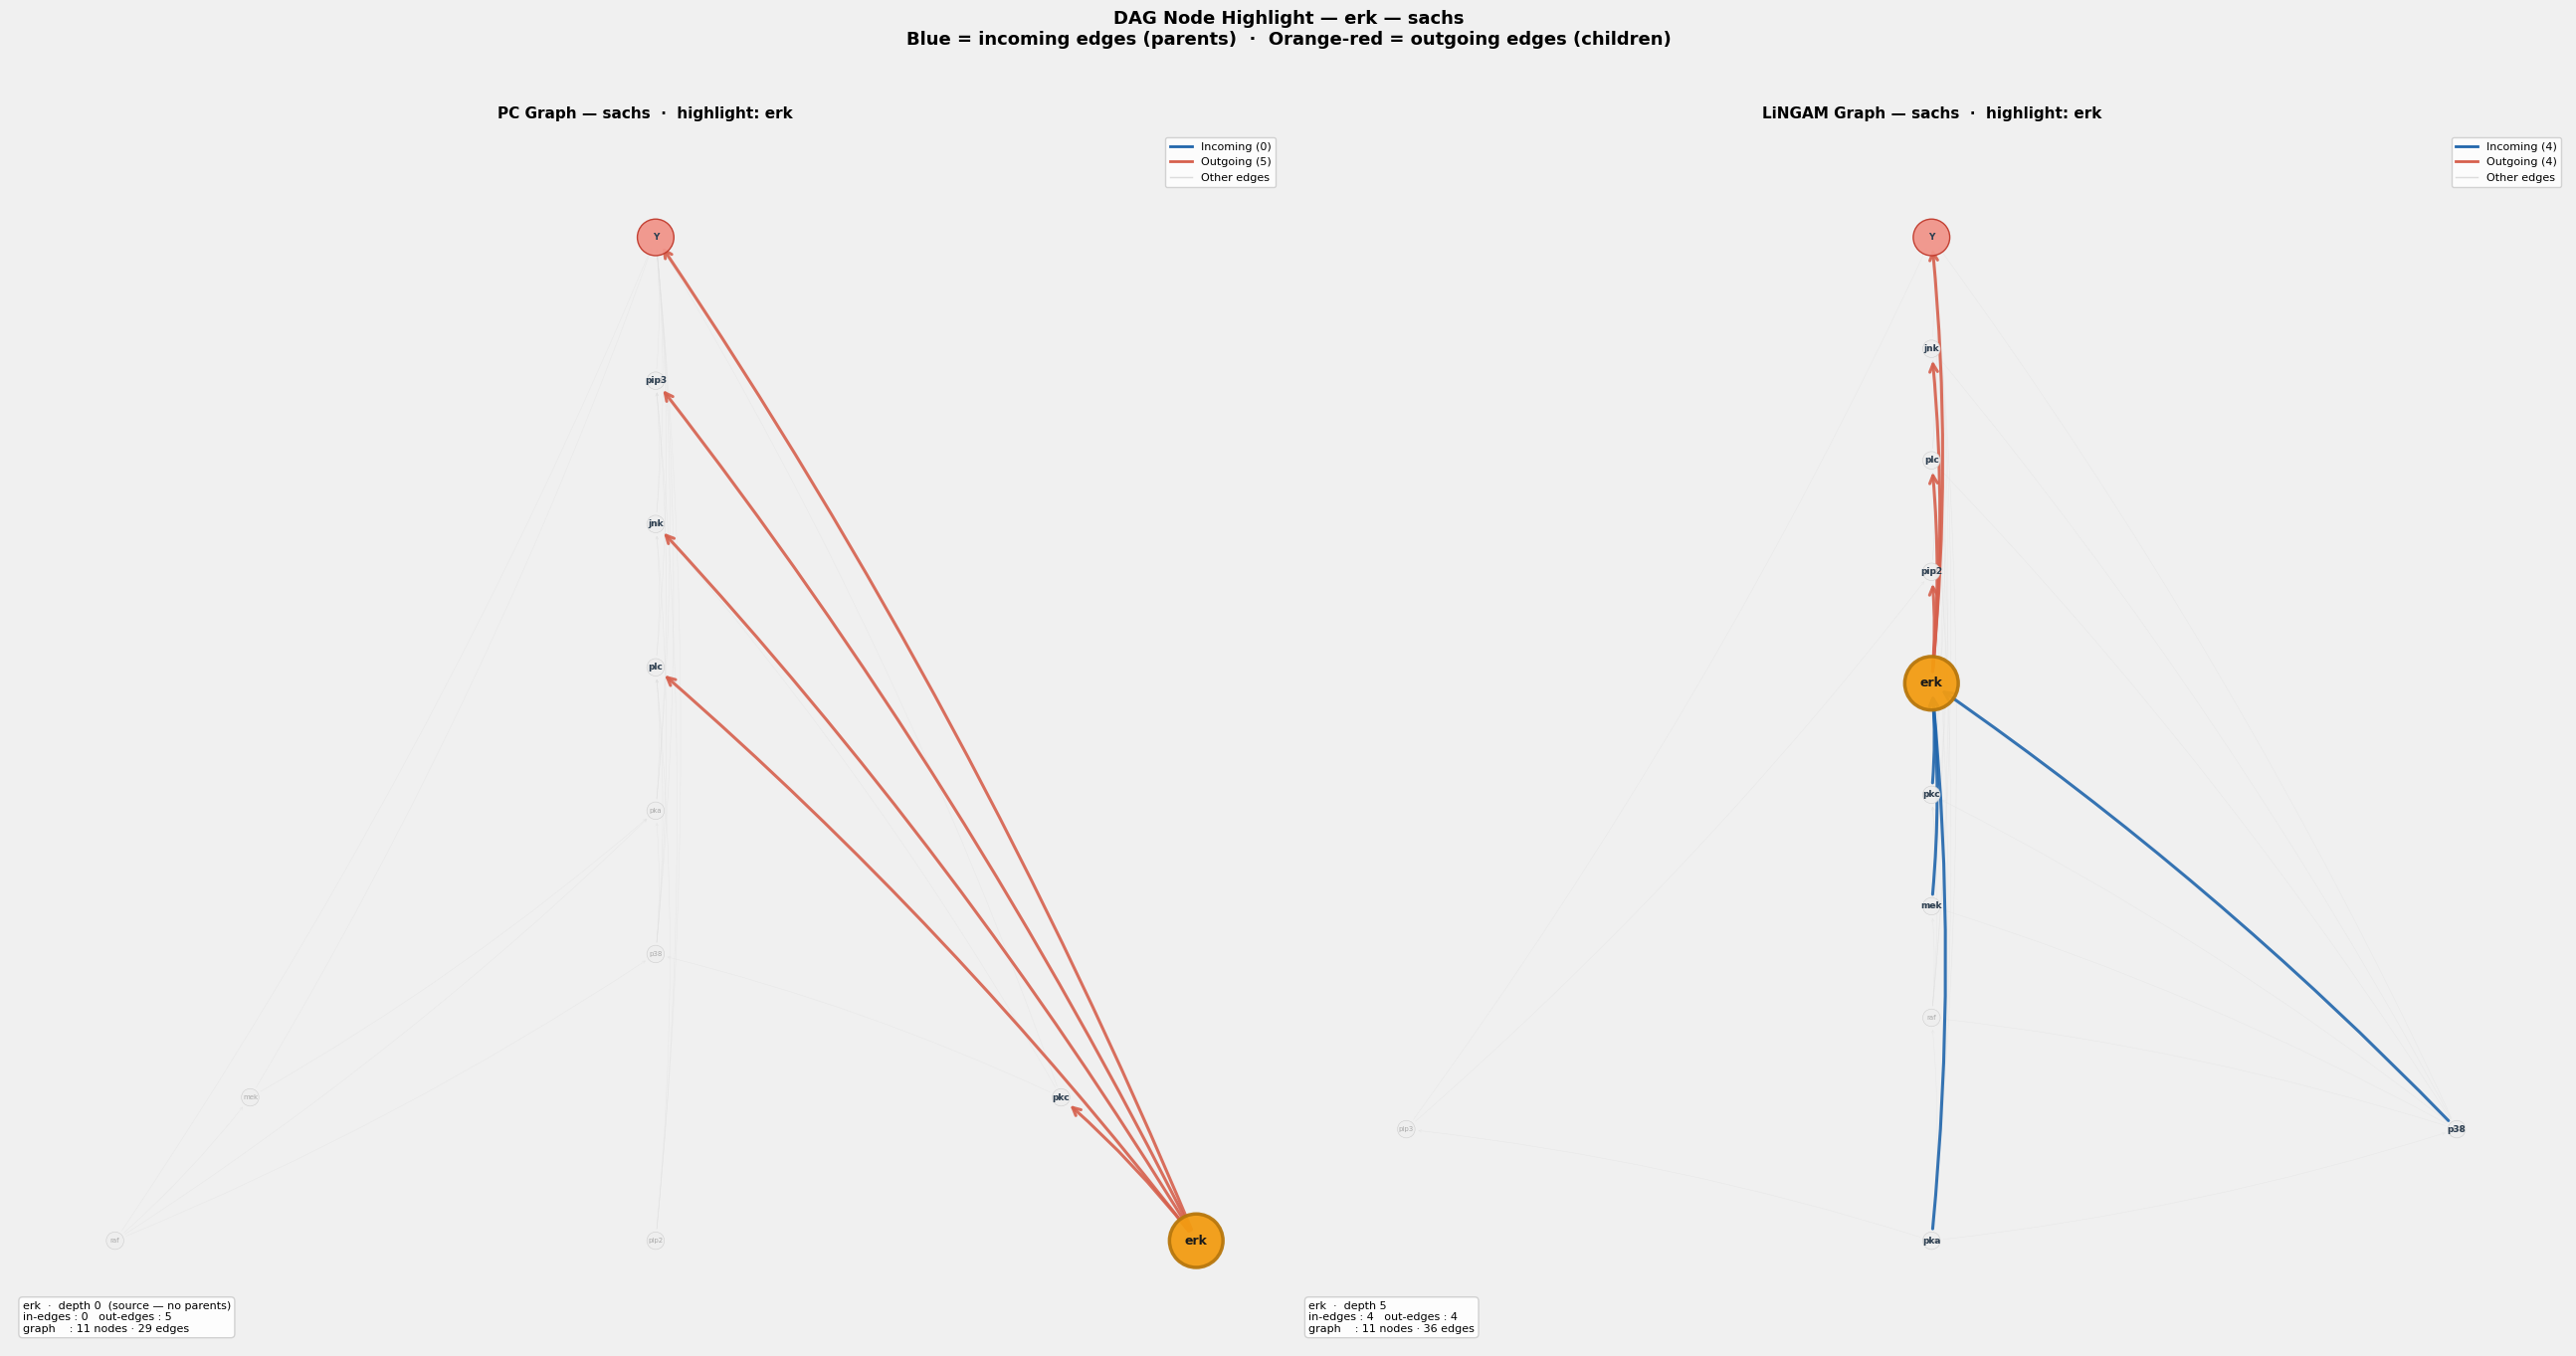

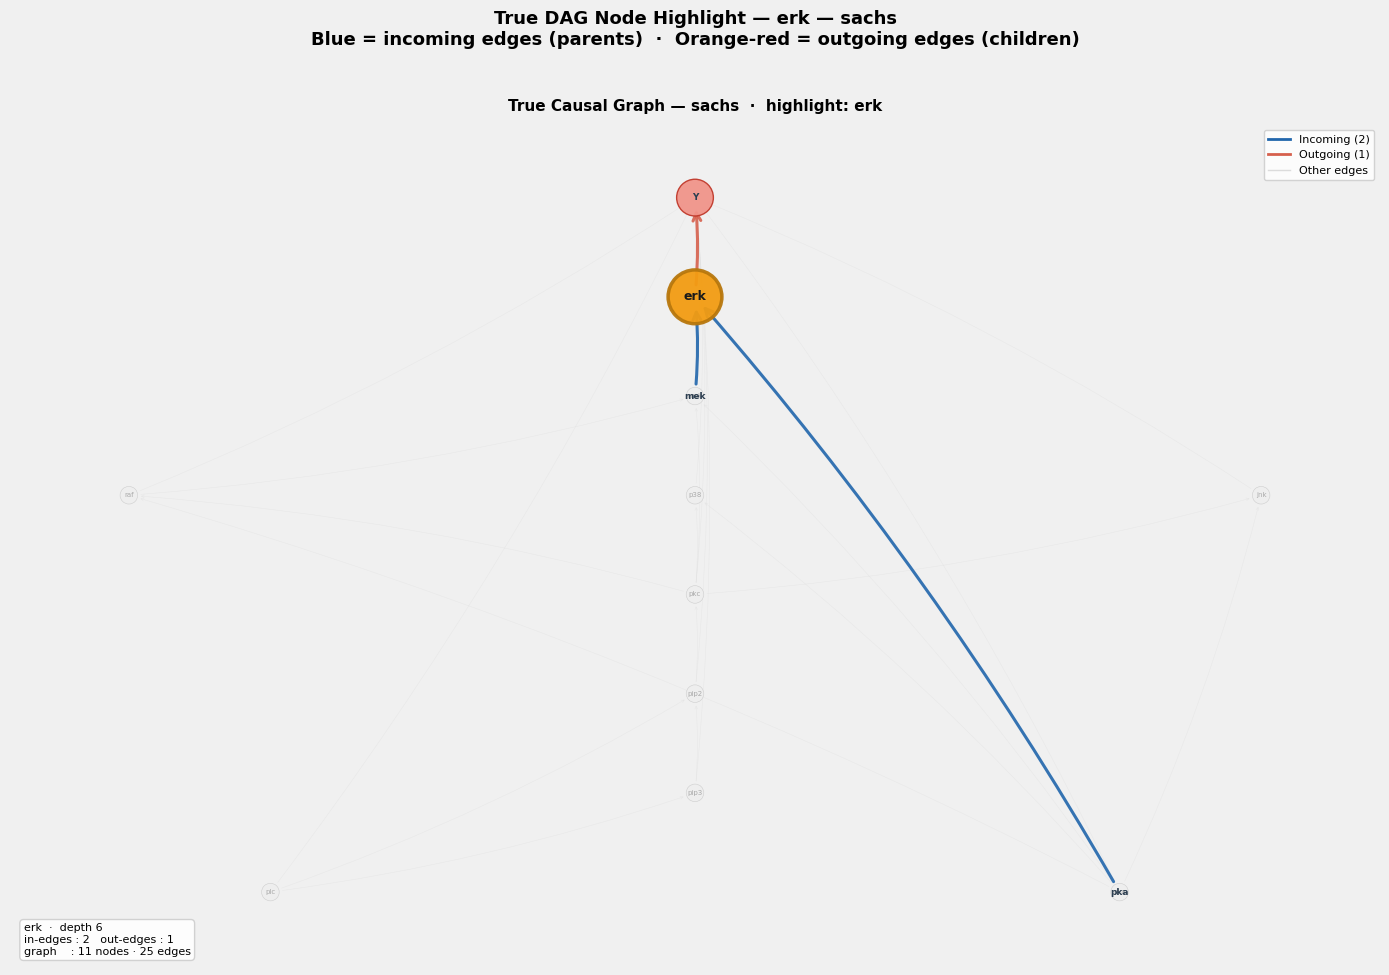

In [11]:
def plot_dag_highlight(protein_name: str, figsize=(26, 14)):
    """
    Draw PC and LiNGAM DAGs side by side with one protein node highlighted.

    Parameters
    ----------
    protein_name : str   e.g. 'pka', 'erk', 'akt'
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.patch.set_facecolor('#f0f0f0')

    draw_dag_highlight(
        axes[0], G_pc, pos_pc, td_pc, src_pc, y_pc, ml_pc,
        title=f'PC Graph — {DATASET}  ·  highlight: {protein_name}',
        highlight_name=protein_name,
        names=pc_names,
    )
    draw_dag_highlight(
        axes[1], G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
        title=f'LiNGAM Graph — {DATASET}  ·  highlight: {protein_name}',
        highlight_name=protein_name,
        names=pc_names,
    )
    fig.suptitle(
        f'DAG Node Highlight — {protein_name} — {DATASET}\n'
        f'Blue = incoming edges (parents)  ·  Orange-red = outgoing edges (children)',
        fontsize=13, fontweight='bold', y=0.99,
    )
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    plt.show()


def plot_dag_highlight_true(protein_name: str, figsize=(14, 10)):
    """Same as plot_dag_highlight but on the True DAG."""
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    fig.patch.set_facecolor('#f0f0f0')
    draw_dag_highlight(
        ax, G_true, pos_true, td_true, src_true, y_true, ml_true,
        title=f'True Causal Graph — {DATASET}  ·  highlight: {protein_name}',
        highlight_name=protein_name,
        names=true_names,
    )
    fig.suptitle(
        f'True DAG Node Highlight — {protein_name} — {DATASET}\n'
        f'Blue = incoming edges (parents)  ·  Orange-red = outgoing edges (children)',
        fontsize=13, fontweight='bold', y=0.99,
    )
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    plt.show()


# ── Example: highlight pka (a well-known Sachs hub protein) ──────────────────
plot_dag_highlight('erk')
plot_dag_highlight_true('erk')

## 10. Graph Sensitivity Score (GSS)

$$\text{GSS}(m,f) = \text{mean}_i\bigl(|\varphi^{(m,\text{PC})}_{i,f}| - |\varphi^{(m,\text{LiNGAM})}_{i,f}|\bigr)$$

Signed: **positive** = PC assigns higher importance; **negative** = LiNGAM assigns higher; **≈0** = both agree.

In [12]:
BASE_METHODS = ['Asymmetric', 'Causal', 'Flow']

CAUSAL_METHOD_PAIRS = [
    ('Asymmetric', 'Asymmetric (PC)',  'Asymmetric (LiNGAM)'),
    ('Causal',     'Causal (PC)',      'Causal (LiNGAM)'),
    ('Flow',       'Flow (PC)',        'Flow (LiNGAM)'),
]

feat_delta = {}
gss_feat   = {}
for label, pc_key, lingam_key in CAUSAL_METHOD_PAIRS:
    if pc_key not in shap_data or lingam_key not in shap_data:
        continue
    abs_pc         = np.abs(shap_data[pc_key])
    abs_lingam     = np.abs(shap_data[lingam_key])
    feat_delta[label] = abs_pc - abs_lingam
    gss_feat[label]   = feat_delta[label].mean(axis=0)

for label in BASE_METHODS:
    if label not in gss_feat:
        continue
    g = gss_feat[label]
    print(f'{label}: mean GSS = {np.mean(g):.4f}  min = {np.min(g):.4f}  max = {np.max(g):.4f}')

# ── A: Feature-level GSS heatmap ─────────────────────────────────────────────
gss_matrix = np.stack([gss_feat[m] for m in BASE_METHODS if m in gss_feat], axis=1)
feat_order = np.argsort(np.abs(gss_matrix).mean(axis=1))[::-1]
abs_max    = float(np.nanmax(np.abs(gss_matrix)))

fig_gss_hmap = go.Figure(go.Heatmap(
    z          = gss_matrix[feat_order].T,
    y          = BASE_METHODS,
    x          = [feature_names[i] for i in feat_order],
    colorscale = 'RdBu',
    zmid=0,
    zmin=-abs_max, zmax=abs_max,
    colorbar   = dict(title=dict(text='GSS', font=dict(size=11))),
    hovertemplate='<b>%{y}</b> — %{x}<br>GSS = %{z:.4f}<extra></extra>',
))
fig_gss_hmap.update_layout(
    title=dict(
        text=(
            f'Feature-Level Graph Sensitivity Score — PC vs LiNGAM — {DATASET}<br>'
            f'<sup>GSS = mean_i(|φ(PC)|−|φ(LiNGAM)|).  '
            f'Red = PC assigns higher importance;  Blue = LiNGAM assigns higher;  White ≈ 0.  '
            f'Sorted by mean |GSS| descending.</sup>'
        ),
        font=dict(size=13),
    ),
    height=310, width=max(700, 60 * n_features + 200),
    xaxis=dict(tickfont=dict(size=10), tickangle=-45, side='bottom'),
    yaxis=dict(tickfont=dict(size=10)),
    margin=dict(l=110, r=80, t=85, b=110),
)
fig_gss_hmap.show()

# ── B: Per-instance magnitude delta box plots ─────────────────────────────────
fig_delta_rows = []
for label, _, _ in CAUSAL_METHOD_PAIRS:
    if label not in feat_delta:
        continue
    for fi in scratch_rank:
        for v in feat_delta[label][:, fi]:
            fig_delta_rows.append(dict(Feature=feature_names[fi], Method=label, Delta=float(v)))

df_delta = pd.DataFrame(fig_delta_rows)
df_delta['Feature'] = pd.Categorical(
    df_delta['Feature'],
    categories=[feature_names[i] for i in scratch_rank], ordered=True
)

fig_delta = px.box(
    df_delta,
    x='Feature', y='Delta', color='Method',
    color_discrete_map={
        'Asymmetric': METHOD_COLORS['Asymmetric'],
        'Causal':     METHOD_COLORS['Causal'],
        'Flow':       METHOD_COLORS['ShapleyFlow'],
    },
    points='outliers',
    title=(
        f'Per-Instance Importance Magnitude Delta |φ(PC)| − |φ(LiNGAM)| — {DATASET}<br>'
        f'<sup>Positive = PC assigns higher importance; negative = LiNGAM assigns higher.</sup>'
    ),
    labels={'Delta': '|φ(PC)| − |φ(LiNGAM)|', 'Feature': ''},
    height=480, width=1000,
)
fig_delta.add_hline(y=0, line=dict(color='black', width=1, dash='dash'))
fig_delta.update_layout(xaxis_tickangle=-40, legend_title_text='Method', margin=dict(t=90, b=80))
fig_delta.show()

# ── C: Method-level GSS summary ────────────────────────────────────────────────
print(f"\n{'Method':<15}  {'Mean GSS':>10}  {'Median GSS':>11}  {'Max |GSS|':>10}")
print('─' * 55)
for label in BASE_METHODS:
    if label not in gss_feat:
        continue
    g = gss_feat[label]
    print(f'  {label:<13}  {np.mean(g):>10.4f}  {np.median(g):>11.4f}  {np.max(np.abs(g)):>10.4f}')

Asymmetric: mean GSS = 0.1775  min = -2.3836  max = 2.7701
Causal: mean GSS = 0.0575  min = -1.1866  max = 0.5117
Flow: mean GSS = 0.4141  min = -23.8241  max = 36.3836



Method             Mean GSS   Median GSS   Max |GSS|
───────────────────────────────────────────────────────
  Asymmetric         0.1775       0.1596      2.7701
  Causal             0.0575       0.1783      1.1866
  Flow               0.4141      -0.2735     36.3836


## 11. Ranking Robustness — Spearman ρ / Top-K Jaccard / True-Parent Precision@K

In [13]:
from scipy.stats import spearmanr

DISC_GRAPHS = ['PC', 'LiNGAM']
K_VALUES    = [3, 5, 10]   # only 10 features total

# ── True Y-parent set from Sachs biology (saved in metadata) ──────────────────
with open(SYNTHETIC_DIR / f'{DATASET}_metadata.json') as _f:
    _meta = json.load(_f)
y_parent_set = set(_meta['y_parent_indices'])
print(f"True Y-parents: {len(y_parent_set)} / {n_features} proteins")
print(f"Parent names: {_meta['y_parent_names']}")
print(f"Random baseline precision: {len(y_parent_set)/n_features:.3f}")
random_baseline = len(y_parent_set) / n_features

scratch_ma = mean_abs_shap(shap_data, 'Scratch')

# ── A: Spearman ρ vs Scratch ──────────────────────────────────────────────────
spearman_data = {}
for meth in BASE_METHODS:
    for g in DISC_GRAPHS:
        k = f'{meth} ({g})'
        if k not in shap_data:
            continue
        rho, _ = spearmanr(mean_abs_shap(shap_data, k), scratch_ma)
        spearman_data[(meth, g)] = float(rho)

spearman_matrix = np.full((len(BASE_METHODS), len(DISC_GRAPHS)), np.nan)
for mi, meth in enumerate(BASE_METHODS):
    for gi, g in enumerate(DISC_GRAPHS):
        if (meth, g) in spearman_data:
            spearman_matrix[mi, gi] = spearman_data[(meth, g)]

fig_spearman = go.Figure(go.Heatmap(
    z            = spearman_matrix,
    x            = DISC_GRAPHS,
    y            = BASE_METHODS,
    colorscale   = 'RdYlGn',
    zmin=0.5, zmax=1.0,
    text         = [[f'{v:.3f}' if not np.isnan(v) else '' for v in row] for row in spearman_matrix],
    texttemplate = '%{text}',
    textfont     = dict(size=14, color='black'),
    colorbar     = dict(title=dict(text='Spearman ρ', font=dict(size=11)),
                        tickvals=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
    hovertemplate='<b>%{y} (%{x})</b> vs Scratch<br>ρ = %{z:.3f}<extra></extra>',
))
fig_spearman.update_layout(
    title=dict(
        text=(
            f'Feature Ranking Correlation vs Scratch (Spearman ρ) — {DATASET}<br>'
            f'<sup>1.0 = identical ranking to the graph-free baseline.  n={n_shap} instances.</sup>'
        ),
        font=dict(size=13),
    ),
    height=250, width=480,
    margin=dict(l=90, r=60, t=90, b=60),
)
fig_spearman.show()

# ── B: Top-K Jaccard vs Scratch ────────────────────────────────────────────────
jaccard_rows = []
for meth in BASE_METHODS:
    for g in DISC_GRAPHS:
        k = f'{meth} ({g})'
        if k not in shap_data:
            continue
        for kv in K_VALUES:
            j = top_k_jaccard(mean_abs_shap(shap_data, k), scratch_ma, kv)
            jaccard_rows.append(dict(Method=meth, Graph=g, K=f'Top-{kv}', Jaccard=j))

df_jacc = pd.DataFrame(jaccard_rows)
fig_jacc = px.bar(
    df_jacc,
    x='Graph', y='Jaccard', color='Method', facet_col='K',
    barmode='group',
    color_discrete_map={
        'Asymmetric': METHOD_COLORS['Asymmetric'],
        'Causal':     METHOD_COLORS['Causal'],
        'Flow':       METHOD_COLORS['ShapleyFlow'],
    },
    range_y=[0, 1.05],
    title=(
        f'Top-K Feature Set Overlap vs Scratch (Jaccard) — {DATASET}<br>'
        f'<sup>1.0 = method selects exactly the same features as the graph-free baseline.</sup>'
    ),
    labels={'Jaccard': 'Jaccard vs Scratch', 'Graph': 'Discovered Graph'},
    height=380, width=900,
)
fig_jacc.update_layout(legend_title_text='Method', margin=dict(t=90, b=60))
fig_jacc.show()

# ── C: True-parent Precision@K ────────────────────────────────────────────────
parent_rows = []
for meth_key, meth_label in [('Scratch', 'Scratch')] + \
                              [(f'{m} ({g})', f'{m} ({g})') for m in BASE_METHODS for g in DISC_GRAPHS]:
    if meth_key not in shap_data:
        continue
    ma = mean_abs_shap(shap_data, meth_key)
    for kv in K_VALUES:
        top_k_idx = set(np.argsort(ma)[-kv:])
        prec = len(top_k_idx & y_parent_set) / kv
        parent_rows.append(dict(Method=meth_label, K=f'Top-{kv}', Precision=prec))

df_parent = pd.DataFrame(parent_rows)
fig_parent = px.bar(
    df_parent,
    x='Method', y='Precision', color='Method',
    facet_col='K',
    barmode='group',
    range_y=[0, 1.05],
    title=(
        f'True Y-Parent Precision@K — {DATASET}<br>'
        f'<sup>Of the top-K proteins by mean|φ|, what fraction are true causal parents of Y (akt)?  '
        f'({len(y_parent_set)} true parents / {n_features} features).  '
        f'Red dashed = random baseline ({random_baseline:.2f}).</sup>'
    ),
    labels={'Precision': 'Precision@K (true Y-parents)', 'Method': ''},
    height=440, width=1150,
)
fig_parent.add_hline(
    y=random_baseline,
    line=dict(color='#d62728', width=1.5, dash='dash'),
    annotation_text=f'random ({random_baseline:.2f})',
    annotation_position='top right',
    annotation_font_size=10,
)
fig_parent.update_layout(showlegend=False, xaxis_tickangle=-30, margin=dict(t=90, b=100))
fig_parent.update_xaxes(tickfont=dict(size=9))
fig_parent.show()

# Stub for TGA (not computed — no True-graph SHAP values available for real data)
tga_data = {}

True Y-parents: 10 / 10 proteins
Parent names: ['raf', 'mek', 'plc', 'pip2', 'pip3', 'erk', 'pka', 'pkc', 'p38', 'jnk']
Random baseline precision: 1.000


## 11.1 — Load True-Graph SHAP Values

Load the Shapley values computed with the **Sachs 2005 consensus DAG** as the oracle
causal graph (generated by `real_data_exploration.ipynb` → *True-graph Shapley Values* cell).
Required for Sign Alignment (11.2) and True-Graph Alignment / TGA (11.3).


In [14]:

# ── Load True-graph SHAP values ───────────────────────────────────────────────
_true_dir = exp_dir / 'true'
TRUE_KEYS = {
    'Asymmetric (True)': _true_dir / 'asymmetric' / 'shapley_values.npy',
    'Causal (True)':     _true_dir / 'causal'     / 'shapley_values.npy',
    'Flow (True)':       _true_dir / 'flow'        / 'shapley_values.npy',
}

# Merge into a combined dict containing all 10 keys (7 original + 3 True-graph)
subset_shap_data = dict(shap_data)
for key, path in TRUE_KEYS.items():
    if path.exists():
        sv = np.load(path)
        subset_shap_data[key] = sv
        print(f'  {key:28s}  shape={sv.shape}  mean|SHAP|={np.abs(sv).mean():.4f}')
    else:
        print(f'  {key:28s}  NOT FOUND: {path}')
        print('  ⚠️  Run real_data_exploration.ipynb → True-graph Shapley cell first.')

N_TRUE_INSTANCES = subset_shap_data.get('Asymmetric (True)', np.zeros((0, 1))).shape[0]
DISC_GRAPHS_TGA  = ['PC', 'LiNGAM']
_has_true = any(k.endswith('(True)') for k in subset_shap_data)
print(f'\nTrue-graph instances loaded : {N_TRUE_INSTANCES}')
print(f'Total keys in subset_shap_data : {len(subset_shap_data)}')


  Asymmetric (True)             NOT FOUND: /Users/juanrios/Documents/master_thesis/data/explainability/sachs/lgbm/true/asymmetric/shapley_values.npy
  ⚠️  Run real_data_exploration.ipynb → True-graph Shapley cell first.
  Causal (True)                 NOT FOUND: /Users/juanrios/Documents/master_thesis/data/explainability/sachs/lgbm/true/causal/shapley_values.npy
  ⚠️  Run real_data_exploration.ipynb → True-graph Shapley cell first.
  Flow (True)                   NOT FOUND: /Users/juanrios/Documents/master_thesis/data/explainability/sachs/lgbm/true/flow/shapley_values.npy
  ⚠️  Run real_data_exploration.ipynb → True-graph Shapley cell first.

True-graph instances loaded : 0
Total keys in subset_shap_data : 7


## 11.2 — Sign Alignment vs True Graph

For each *(method, discovered-graph)* pair, what fraction of instances assign the
**same sign** to a feature's attribution as the True-graph oracle?

$$\text{SignAlign}(m, g, f) = \frac{1}{n}\sum_i \mathbf{1}\!\left[\text{sign}(\varphi^{(m,g)}_{i,f}) = \text{sign}(\varphi^{(m,\text{True})}_{i,f})\right]$$

- **1.0** — signs always agree with the True-graph attribution.
- **0.5** — random (half positive, half negative).
- **0.0** — signs always disagree.


In [15]:

if not _has_true:
    print('⚠️  True-graph SHAP not found — run cell 11.1 first.')
else:
    sign_align = compute_sign_alignment(subset_shap_data, BASE_METHODS, DISC_GRAPHS_TGA)

    if sign_align:
        # ── A: Feature-level heatmap ─────────────────────────────────────────
        sa_keys      = [(m, g) for m in BASE_METHODS for g in DISC_GRAPHS_TGA if (m, g) in sign_align]
        sa_labels    = [f'{m} ({g})' for m, g in sa_keys]
        sa_matrix    = np.stack([sign_align[k] for k in sa_keys], axis=1)  # (n_feat, n_combos)
        feat_sa_ord  = np.argsort(sa_matrix.mean(axis=1))                  # ascending = worst first

        fig_sign_align = go.Figure(go.Heatmap(
            z          = sa_matrix[feat_sa_ord],
            x          = sa_labels,
            y          = [feature_names[i] for i in feat_sa_ord],
            colorscale = 'RdYlGn',
            zmin=0, zmax=1.0,
            colorbar   = dict(
                title=dict(text='Sign Align', font=dict(size=11)),
                tickvals=[0, 0.25, 0.5, 0.75, 1.0],
                ticktext=['0 (always opp.)', '0.25', '0.5 (random)', '0.75', '1.0 (perfect)'],
            ),
            hovertemplate='<b>%{y}</b> — %{x}<br>Sign Align = %{z:.3f}<extra></extra>',
        ))
        fig_sign_align.update_layout(
            title=dict(
                text=(
                    f'Sign Alignment vs True Graph — {DATASET}<br>'
                    f'<sup>Fraction of instances where sign(φ_discovered) = sign(φ_true).  '
                    f'Sorted by worst mean alignment.  N={N_TRUE_INSTANCES} instances.</sup>'
                ),
                font=dict(size=13),
            ),
            height=max(400, 30 * n_features + 120),
            width=760,
            yaxis=dict(tickfont=dict(size=10)),
            xaxis=dict(tickfont=dict(size=10), tickangle=-25),
            margin=dict(l=80, r=80, t=90, b=80),
        )
        fig_sign_align.show()

        # ── B: Overall summary bar chart ──────────────────────────────────────
        sa_rows = []
        for meth in BASE_METHODS:
            for g in DISC_GRAPHS_TGA:
                if (meth, g) not in sign_align:
                    continue
                arr = sign_align[(meth, g)]
                sa_rows.append(dict(
                    Method=meth, Graph=g,
                    MeanAlign=float(np.nanmean(arr)),
                    label=f'{meth} ({g})',
                ))
        df_sa = pd.DataFrame(sa_rows)

        fig_sa_bar = px.bar(
            df_sa, x='label', y='MeanAlign', color='Method', facet_col='Graph',
            barmode='group',
            color_discrete_map={
                'Asymmetric': METHOD_COLORS['Asymmetric'],
                'Causal':     METHOD_COLORS['Causal'],
                'Flow':       METHOD_COLORS['ShapleyFlow'],
            },
            range_y=[0, 1.05],
            title=(
                f'Overall Sign Alignment vs True Graph — {DATASET}<br>'
                f'<sup>Mean across features of per-feature sign agreement with True-graph oracle.</sup>'
            ),
            labels={'MeanAlign': 'Mean Sign Alignment', 'label': ''},
            height=380, width=700,
        )
        fig_sa_bar.add_hline(y=0.5, line=dict(color='gray', width=1, dash='dot'),
                             annotation_text='random (0.5)', annotation_font_size=9)
        fig_sa_bar.add_hline(y=1.0, line=dict(color='green', width=1, dash='dot'))
        fig_sa_bar.update_layout(showlegend=True, xaxis_tickangle=-20, margin=dict(t=90, b=80))
        fig_sa_bar.show()

        # ── C: Numeric summary ────────────────────────────────────────────────
        print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean SignAlign':>15}  {'Feat<0.5':>9}")
        print('─' * 55)
        for row in sa_rows:
            arr = sign_align[(row['Method'], row['Graph'])]
            print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
                  f"{row['MeanAlign']:>15.4f}  {(arr<0.5).sum():>9d}")


⚠️  True-graph SHAP not found — run cell 11.1 first.


## 11.3 — Magnitude TGA vs True DAG

How much does the **magnitude** of a discovered-graph attribution differ from the True-graph oracle?

$$\text{TGA}(m, g, f) = \frac{1}{n}\sum_i\left(|\varphi^{(m,g)}_{i,f}| - |\varphi^{(m,\text{True})}_{i,f}|\right)$$

- **Positive** — discovered graph over-estimates True-graph importance.
- **Negative** — discovered graph under-estimates True-graph importance.
- **≈ 0** — magnitude agrees with True-graph oracle.


In [16]:

if not _has_true:
    print('⚠️  True-graph SHAP not found — run cell 11.1 first.')
    tga_data = {}
else:
    tga_data, _zero_feat_sets = compute_tga(
        subset_shap_data, feature_names, BASE_METHODS, DISC_GRAPHS_TGA
    )

    if tga_data:
        # ── A: Feature-level TGA heatmap ──────────────────────────────────────
        tga_keys     = [(m, g) for m in BASE_METHODS for g in DISC_GRAPHS_TGA if (m, g) in tga_data]
        tga_labels   = [f'{m} ({g})' for m, g in tga_keys]
        tga_matrix   = np.stack([tga_data[k] for k in tga_keys], axis=1)   # (n_feat, n_combos)
        tga_feat_ord = np.argsort(np.abs(tga_matrix).mean(axis=1))[::-1]   # descending |TGA|
        abs_max_tga  = float(np.max(np.abs(tga_matrix)))

        fig_tga_hmap = go.Figure(go.Heatmap(
            z          = tga_matrix[tga_feat_ord].T,
            x          = [feature_names[i] for i in tga_feat_ord],
            y          = tga_labels,
            colorscale = 'RdBu',
            zmid=0,
            zmin=-abs_max_tga, zmax=abs_max_tga,
            colorbar   = dict(title=dict(text='TGA', font=dict(size=11))),
            hovertemplate='<b>%{y}</b> — %{x}<br>TGA = %{z:.4f}<extra></extra>',
        ))
        fig_tga_hmap.update_layout(
            title=dict(
                text=(
                    f'Feature-Level Magnitude TGA vs True DAG — {DATASET}<br>'
                    f'<sup>TGA = mean_i(|φ(disc)| − |φ(true)|).  '
                    f'Red = disc overestimates True;  Blue = underestimates;  White ≈ agrees.  '
                    f'Sorted by mean |TGA| descending.  N={N_TRUE_INSTANCES} instances.</sup>'
                ),
                font=dict(size=13),
            ),
            height=310,
            width=max(700, 60 * n_features + 300),
            xaxis=dict(tickfont=dict(size=10), tickangle=-45, side='bottom'),
            yaxis=dict(tickfont=dict(size=10)),
            margin=dict(l=130, r=80, t=85, b=110),
        )
        fig_tga_hmap.show()

        # ── B: Overall summary bar chart ──────────────────────────────────────
        tga_rows = []
        for meth in BASE_METHODS:
            for g in DISC_GRAPHS_TGA:
                if (meth, g) not in tga_data:
                    continue
                arr = tga_data[(meth, g)]
                tga_rows.append(dict(
                    Method=meth, Graph=g,
                    MeanTGA=float(np.mean(arr)),
                    label=f'{meth} ({g})',
                ))
        df_tga = pd.DataFrame(tga_rows)

        fig_tga_bar = px.bar(
            df_tga, x='label', y='MeanTGA', color='Method', facet_col='Graph',
            barmode='group',
            color_discrete_map={
                'Asymmetric': METHOD_COLORS['Asymmetric'],
                'Causal':     METHOD_COLORS['Causal'],
                'Flow':       METHOD_COLORS['ShapleyFlow'],
            },
            title=(
                f'Overall Magnitude TGA vs True DAG — {DATASET}<br>'
                f'<sup>Positive = disc overestimates True magnitude; '
                f'negative = underestimates; near 0 = magnitudes agree.</sup>'
            ),
            labels={'MeanTGA': 'Mean TGA', 'label': ''},
            height=380, width=700,
        )
        fig_tga_bar.add_hline(y=0, line=dict(color='gray', width=1.5, dash='dot'))
        fig_tga_bar.update_layout(showlegend=True, xaxis_tickangle=-20, margin=dict(t=90, b=80))
        fig_tga_bar.show()

        # ── C: Numeric summary ────────────────────────────────────────────────
        print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean TGA':>10}  {'Median TGA':>11}  {'Max |TGA|':>10}")
        print('─' * 60)
        for row in tga_rows:
            arr = tga_data[(row['Method'], row['Graph'])]
            print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
                  f"{row['MeanTGA']:>10.4f}  {np.median(arr):>11.4f}  "
                  f"{np.max(np.abs(arr)):>10.4f}")
    else:
        tga_data = {}
        print('⚠️  No TGA data computed — check True-graph SHAP arrays are loaded.')


⚠️  True-graph SHAP not found — run cell 11.1 first.


## 12. Sign Stability Score (SSS)

$$\text{SSS}(m,f) = \frac{1}{n}\sum_i \mathbf{1}\!\left[\text{sign}(\varphi^{(m,\text{PC})}_{i,f}) = \text{sign}(\varphi^{(m,\text{LiNGAM})}_{i,f})\right]$$

1 = sign always the same under PC and LiNGAM; 0 = always flips.

In [17]:
sss_feat = compute_sss(shap_data, BASE_METHODS)

for meth, arr in sss_feat.items():
    print(f'{meth}: mean SSS = {np.nanmean(arr):.4f}  '
          f'min SSS = {np.nanmin(arr):.4f}  '
          f'features with SSS<0.5 = {(arr < 0.5).sum()}')

_sss_color = {
    'Asymmetric': METHOD_COLORS['Asymmetric'],
    'Causal':     METHOD_COLORS['Causal'],
    'Flow':       METHOD_COLORS['ShapleyFlow'],
}

# ── A: Feature-level SSS heatmap ──────────────────────────────────────────────
sss_matrix   = np.stack([sss_feat[m] for m in BASE_METHODS if m in sss_feat], axis=1)
sss_methods  = [m for m in BASE_METHODS if m in sss_feat]
sss_feat_ord = np.argsort(np.nanmean(sss_matrix, axis=1))  # ascending (worst first)

fig_sign_hmap = go.Figure(go.Heatmap(
    z          = sss_matrix[sss_feat_ord].T,
    y          = sss_methods,
    x          = [feature_names[i] for i in sss_feat_ord],
    colorscale = 'RdYlGn',
    zmin=0.0, zmax=1.0,
    colorbar   = dict(
        title=dict(text='SSS', font=dict(size=11)),
        tickvals=[0.0, 0.25, 0.5, 0.75, 1.0],
        ticktext=['0 (always flips)', '0.25', '0.5', '0.75', '1 (always agrees)'],
    ),
    hovertemplate='<b>%{y}</b> — %{x}<br>SSS = %{z:.3f}<extra></extra>',
))
fig_sign_hmap.update_layout(
    title=dict(
        text=(
            f'Feature-Level Sign Stability Score — PC vs LiNGAM — {DATASET}<br>'
            f'<sup>SSS = fraction of instances where SHAP sign agrees between PC and LiNGAM.  '
            f'Sorted left→right by mean SSS ascending (most unstable first).</sup>'
        ),
        font=dict(size=13),
    ),
    height=310, width=max(700, 60 * n_features + 200),
    xaxis=dict(tickfont=dict(size=10), tickangle=-45, side='bottom'),
    yaxis=dict(tickfont=dict(size=10)),
    margin=dict(l=110, r=80, t=85, b=110),
)
fig_sign_hmap.show()

# ── B: Method-level mean SSS bar chart ────────────────────────────────────────
fig_sign_bar = go.Figure()
for meth in BASE_METHODS:
    if meth not in sss_feat:
        continue
    arr = sss_feat[meth]
    fig_sign_bar.add_trace(go.Bar(
        x=[meth], y=[float(np.nanmean(arr))],
        name=meth,
        marker_color=_sss_color[meth],
        hovertemplate=f'<b>{meth}</b><br>Mean SSS = %{{y:.4f}}<extra></extra>',
    ))
fig_sign_bar.add_hline(y=0.5, line=dict(color='#d62728', dash='dash', width=1),
                       annotation_text='0.5 (random)', annotation_font_size=9)
fig_sign_bar.update_layout(
    title=dict(
        text=f'Overall Sign Stability Score (Mean SSS) — {DATASET}',
        font=dict(size=13),
    ),
    yaxis=dict(title='Mean SSS', range=[0, 1.05]),
    showlegend=False,
    height=340, width=420,
    margin=dict(l=70, r=30, t=80, b=60),
)
fig_sign_bar.show()

# ── C: Numeric summary ─────────────────────────────────────────────────────────
print(f"\n{'Method':<15}  {'Mean SSS':>10}  {'Median SSS':>11}  {'Min SSS':>9}  {'SSS<0.5':>8}")
print('─' * 60)
for meth in BASE_METHODS:
    if meth not in sss_feat:
        continue
    arr   = sss_feat[meth]
    valid = ~np.isnan(arr)
    print(f'  {meth:<13}  {np.nanmean(arr):>10.4f}  {np.nanmedian(arr):>11.4f}  '
          f'{np.nanmin(arr):>9.4f}  {(arr[valid]<0.5).sum():>8d}')

Asymmetric: mean SSS = 0.8140  min SSS = 0.5700  features with SSS<0.5 = 0
Causal: mean SSS = 0.7400  min SSS = 0.5100  features with SSS<0.5 = 0
Flow: mean SSS = 0.7812  min SSS = 0.4948  features with SSS<0.5 = 1



Method             Mean SSS   Median SSS    Min SSS   SSS<0.5
────────────────────────────────────────────────────────────
  Asymmetric         0.8140       0.8650     0.5700         0
  Causal             0.7400       0.7350     0.5100         0
  Flow               0.7812       0.7980     0.4948         1


## 13. Method Recommendation Summary

In [18]:
def _parent_prec(method_key, k):
    if method_key not in shap_data:
        return np.nan
    ma      = mean_abs_shap(shap_data, method_key)
    top_idx = set(np.argsort(ma)[-k:])
    return len(top_idx & y_parent_set) / k


K_SUMMARY = 5   # use Top-5 for summary (half of all 10 proteins)

summary_rows = []
for meth in BASE_METHODS:
    pc_key = f'{meth} (PC)'
    lg_key = f'{meth} (LiNGAM)'

    gss_mean   = float(gss_feat[meth].mean())         if meth in gss_feat     else np.nan
    rho_pc_scr = spearman_data.get((meth, 'PC'),     np.nan)
    rho_lg_scr = spearman_data.get((meth, 'LiNGAM'), np.nan)

    j5_pc  = top_k_jaccard(mean_abs_shap(shap_data, pc_key), scratch_ma, K_SUMMARY) \
              if pc_key in shap_data else np.nan
    j5_lg  = top_k_jaccard(mean_abs_shap(shap_data, lg_key), scratch_ma, K_SUMMARY) \
              if lg_key in shap_data else np.nan

    pp5_pc = _parent_prec(pc_key, K_SUMMARY)
    pp5_lg = _parent_prec(lg_key, K_SUMMARY)

    sss_mean_meth = float(np.nanmean(sss_feat[meth])) if meth in sss_feat else np.nan

    # TGA: mean absolute deviation from True-graph magnitudes (lower = better agreement)
    tga_pc = float(np.mean(np.abs(tga_data[(meth, 'PC')]))) \
             if tga_data and (meth, 'PC') in tga_data else np.nan
    tga_lg = float(np.mean(np.abs(tga_data[(meth, 'LiNGAM')]))) \
             if tga_data and (meth, 'LiNGAM') in tga_data else np.nan

    summary_rows.append(dict(
        Method   = meth,
        GSS      = gss_mean,
        SSS      = sss_mean_meth,
        rho_pc   = rho_pc_scr,
        rho_lg   = rho_lg_scr,
        J5_pc    = j5_pc,
        J5_lg    = j5_lg,
        PP5_pc   = pp5_pc,
        PP5_lg   = pp5_lg,
        TGA_pc   = tga_pc,
        TGA_lg   = tga_lg,
    ))

# Scratch reference row
pp5_scratch = _parent_prec('Scratch', K_SUMMARY)
summary_rows.insert(0, dict(
    Method='Scratch', GSS=np.nan, SSS=np.nan,
    rho_pc=np.nan, rho_lg=np.nan,
    J5_pc=np.nan, J5_lg=np.nan,
    PP5_pc=pp5_scratch, PP5_lg=pp5_scratch,
    TGA_pc=np.nan, TGA_lg=np.nan,
))

df_summary = pd.DataFrame(summary_rows)

COLS = [
    ('Method',  'Method'),
    ('GSS',     f'GSS\n(PC↔LiNGAM) ↓'),
    ('SSS',     f'SSS\n(PC↔LiNGAM) ↑'),
    ('rho_pc',  'ρ(PC–Scratch) ↑'),
    ('rho_lg',  'ρ(LiNGAM–Scratch) ↑'),
    ('J5_pc',   f'J{K_SUMMARY}\n(PC–Scratch) ↑'),
    ('J5_lg',   f'J{K_SUMMARY}\n(LiNGAM–Scratch) ↑'),
    ('PP5_pc',  f'P@{K_SUMMARY}\n(PC) ↑'),
    ('PP5_lg',  f'P@{K_SUMMARY}\n(LiNGAM) ↑'),
    ('TGA_pc',  'mTGA\n(PC) ↓'),
    ('TGA_lg',  'mTGA\n(LiNGAM) ↓'),
]

col_keys    = [c[0] for c in COLS]
col_headers = [c[1] for c in COLS]

def fmt(v):
    if isinstance(v, str): return v
    if np.isnan(v):         return '—'
    return f'{v:.3f}'

LOWER_BETTER  = {'GSS', 'TGA_pc', 'TGA_lg'}
HIGHER_BETTER = {'SSS', 'rho_pc', 'rho_lg', 'J5_pc', 'J5_lg', 'PP5_pc', 'PP5_lg'}

cell_vals   = []
cell_colors = []
n_rows_tbl  = len(df_summary)

for key in col_keys:
    vals  = df_summary[key].tolist()
    fmtd  = [fmt(v) for v in vals]
    cell_vals.append(fmtd)

    numeric   = [v if (not isinstance(v, str) and not np.isnan(v)) else None for v in vals]
    causal_v  = [(i, v) for i, v in enumerate(numeric) if v is not None and i > 0]

    best_i = None
    if causal_v:
        if key in LOWER_BETTER:
            best_i = min(causal_v, key=lambda x: x[1])[0]
        elif key in HIGHER_BETTER:
            best_i = max(causal_v, key=lambda x: x[1])[0]

    row_colors = []
    for i in range(n_rows_tbl):
        if i == 0:
            row_colors.append('#eaf4fb')
        elif i == best_i:
            row_colors.append('#d5f5e3')
        else:
            row_colors.append('#f8f9fa' if i % 2 == 0 else 'white')
    cell_colors.append(row_colors)

fig_summary = go.Figure(go.Table(
    header=dict(
        values     = [f'<b>{h}</b>' for h in col_headers],
        fill_color = '#2c3e50',
        font       = dict(color='white', size=10),
        align      = 'center',
        height     = 52,
    ),
    cells=dict(
        values     = cell_vals,
        fill_color = cell_colors,
        align      = 'center',
        height     = 40,
        font       = dict(size=13),
    ),
))
fig_summary.update_layout(
    title=dict(
        text=(
            f'Method Recommendation Summary — {DATASET}<br>'
            f'<sup>Green = best among causal methods.  '
            f'Blue = Scratch baseline.  '
            f'↑ higher is better  ↓ lower is better.</sup>'
        ),
        font=dict(size=13),
    ),
    height=max(300, 60 * n_rows_tbl + 140),
    width=1100,
    margin=dict(l=20, r=20, t=90, b=20),
)
fig_summary.show()


## 14. Edge Recovery — PC & LiNGAM vs True DAG

In [19]:
# Load train-only adjacency matrices (X-only block)
true_adj_xx         = true_adj[:n_features, :n_features]
pc_train_adj_xx     = np.load(CAUSAL_DIR / f'{DATASET}_pc_train_adjacency.npy')
lingam_train_adj_xx = np.load(CAUSAL_DIR / f'{DATASET}_lingam_train_adjacency.npy')

pc_prec,     pc_rec,     pc_f1     = edge_recovery(true_adj, pc_adj)
lingam_prec, lingam_rec, lingam_f1 = edge_recovery(true_adj, lingam_adj)

pc_prec_xx,     pc_rec_xx,     pc_f1_xx     = edge_recovery(true_adj_xx, pc_train_adj_xx)
lingam_prec_xx, lingam_rec_xx, lingam_f1_xx = edge_recovery(true_adj_xx, lingam_train_adj_xx)

print(f"{'Edge Recovery (full n+1 × n+1 adj)':<40} {'PC':>8} {'LiNGAM':>10}")
print('─' * 60)
print(f"  {'Precision':<38} {pc_prec:>8.3f} {lingam_prec:>10.3f}")
print(f"  {'Recall':<38} {pc_rec:>8.3f} {lingam_rec:>10.3f}")
print(f"  {'F1':<38} {pc_f1:>8.3f} {lingam_f1:>10.3f}")

print(f"\n{'Edge Recovery (X-only train adj)':<40} {'PC':>8} {'LiNGAM':>10}")
print('─' * 60)
print(f"  {'Precision':<38} {pc_prec_xx:>8.3f} {lingam_prec_xx:>10.3f}")
print(f"  {'Recall':<38} {pc_rec_xx:>8.3f} {lingam_rec_xx:>10.3f}")
print(f"  {'F1':<38} {pc_f1_xx:>8.3f} {lingam_f1_xx:>10.3f}")

Edge Recovery (full n+1 × n+1 adj)             PC     LiNGAM
────────────────────────────────────────────────────────────
  Precision                                 0.448      0.472
  Recall                                    0.520      0.680
  F1                                        0.481      0.557

Edge Recovery (X-only train adj)               PC     LiNGAM
────────────────────────────────────────────────────────────
  Precision                                 0.158      0.269
  Recall                                    0.200      0.467
  F1                                        0.176      0.341


## 15. Adjacency Matrix Heatmap

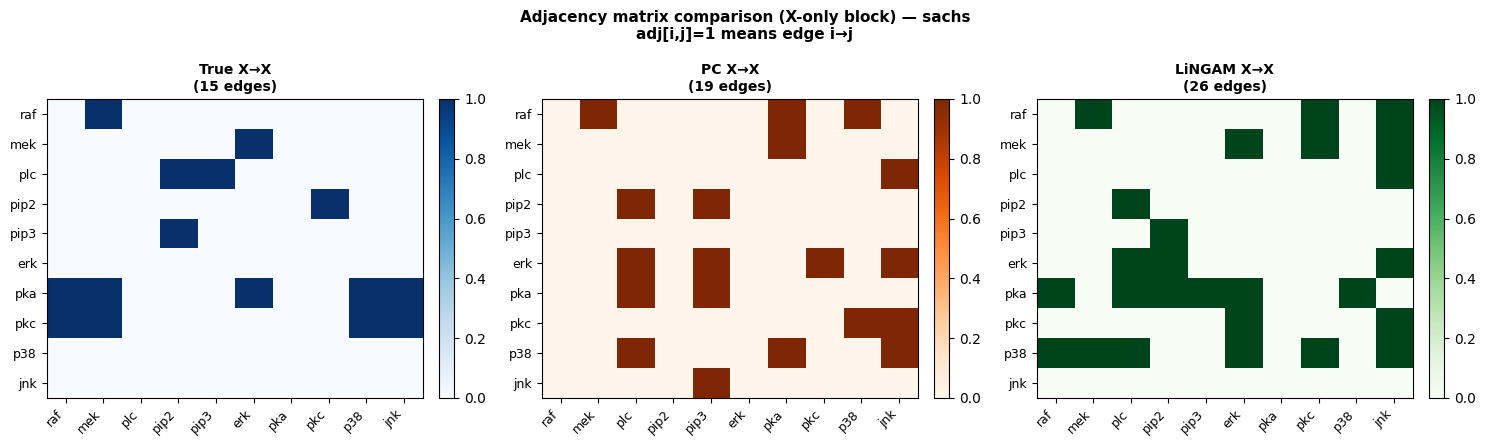

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mat, title_lbl, cmap in [
    (axes[0], true_adj_xx,         'True X→X',    'Blues'),
    (axes[1], pc_train_adj_xx,     'PC X→X',      'Oranges'),
    (axes[2], lingam_train_adj_xx, 'LiNGAM X→X',  'Greens'),
]:
    im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(n_features))
    ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n_features))
    ax.set_yticklabels(feature_names, fontsize=9)
    ax.set_title(f'{title_lbl}\n({int(mat.sum())} edges)', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f'Adjacency matrix comparison (X-only block) — {DATASET}\nadj[i,j]=1 means edge i→j',
    fontweight='bold', fontsize=11
)
plt.tight_layout()
plt.show()

## 16. Feature Importance CSV Export

In [21]:
rows_fi = []
for feat_i, feat in enumerate(feature_names):
    row = {
        'feature':     feat,
        'true_parent': feat_i in y_parent_set,
    }
    for method_key, sv in shap_data.items():
        col = method_key.replace(' ', '_').replace('(', '').replace(')', '')
        row[f'{col}_mean_shap']     = float(sv.mean(axis=0)[feat_i])
        row[f'{col}_mean_abs_shap'] = float(np.abs(sv).mean(axis=0)[feat_i])
    rows_fi.append(row)

df_fi = pd.DataFrame(rows_fi).set_index('feature')

# Add rank columns
for col in [c for c in df_fi.columns if c.endswith('_mean_abs_shap')]:
    rank_col = col.replace('_mean_abs_shap', '_rank')
    df_fi[rank_col] = df_fi[col].rank(ascending=False, method='min').astype(int)

# Interleave per-method: mean_shap / mean_abs_shap / rank
abs_cols  = [c for c in df_fi.columns if c.endswith('_mean_abs_shap')]
shap_cols = [c.replace('_mean_abs_shap', '_mean_shap') for c in abs_cols]
rank_cols = [c.replace('_mean_abs_shap', '_rank')      for c in abs_cols]
ordered   = ['true_parent'] + [c for trio in zip(shap_cols, abs_cols, rank_cols) for c in trio]
df_fi = df_fi[ordered].sort_values(abs_cols[0], ascending=False)

out_path = EXPLAINABILITY_DIR / DATASET / f'feature_importance_{DATASET}.csv'
out_path.parent.mkdir(parents=True, exist_ok=True)
df_fi.to_csv(out_path, sep=';', decimal=',')
print(f'Saved → {out_path}')
print(f'Shape  : {df_fi.shape}  ({n_features} features × {len(abs_cols)} methods × 3 metrics)')
df_fi

Saved → /Users/juanrios/Documents/master_thesis/data/explainability/sachs/feature_importance_sachs.csv
Shape  : (10, 22)  (10 features × 7 methods × 3 metrics)


,true_parent,Scratch_mean_shap,Scratch_mean_abs_shap,Scratch_rank,Asymmetric_PC_mean_shap,Asymmetric_PC_mean_abs_shap,Asymmetric_PC_rank,Causal_PC_mean_shap,Causal_PC_mean_abs_shap,Causal_PC_rank,...,Flow_PC_rank,Asymmetric_LiNGAM_mean_shap,Asymmetric_LiNGAM_mean_abs_shap,Asymmetric_LiNGAM_rank,Causal_LiNGAM_mean_shap,Causal_LiNGAM_mean_abs_shap,Causal_LiNGAM_rank,Flow_LiNGAM_mean_shap,Flow_LiNGAM_mean_abs_shap,Flow_LiNGAM_rank
feature,,,,,,,,,,,,,,,,,,,,,
erk,True,-14.322513,40.431243,1,-24.581741,42.353180,1,-11.217558,40.391875,1,...,1,-8.227122,39.583066,1,-11.452148,40.727093,1,-0.807942,9.829933,4
pka,True,-4.614743,17.209088,2,-1.906667,19.562432,2,-6.703224,17.598895,2,...,5,-12.000056,19.276861,2,-7.126770,18.785485,2,-0.637070,28.947871,1
mek,True,-3.179536,10.287468,3,-0.039335,9.223953,3,-4.439662,11.119388,3,...,3,-4.327603,11.607569,3,-4.598467,11.037550,3,-2.560068,11.671643,3
plc,True,-1.260307,3.680643,4,1.311440,3.212333,4,0.067431,4.103207,4,...,8,1.020178,2.951698,4,0.505573,3.621731,4,-0.060372,0.878035,9
pip2,True,0.359340,1.199397,5,0.545850,1.067272,9,0.005280,3.107945,6,...,6,0.201900,1.482579,6,0.223230,2.913081,5,0.333997,0.927215,8
jnk,True,-0.338833,1.151696,6,-0.207835,1.535688,5,-0.327429,2.882847,7,...,9,-0.192449,1.492356,5,-0.341709,2.534260,8,-0.025674,0.210879,10
p38,True,-0.132096,1.148571,7,0.539129,1.306003,8,0.116272,3.282862,5,...,4,-0.004965,1.219556,7,0.049185,2.771194,6,-2.950330,12.374407,2
raf,True,0.232167,1.056526,8,0.787881,1.317523,7,-0.170266,1.275559,10,...,2,0.359486,1.160196,8,-0.110361,1.109769,10,-1.819289,4.475166,6
pkc,True,-0.146103,0.949944,9,0.383318,1.056374,10,-0.309183,1.361644,9,...,7,-0.300574,0.894563,9,-0.145061,1.170857,9,-0.955786,9.217086,5
